In [2]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

# Set classic plot style
plt.style.use('classic')

In [32]:
# Define groups based on 'miso_data' and the previous 'mosi_data'
def group_miso_data(row):
    
    miso = str(row['miso_data'])
    previous_mosi = str(row['previous_mosi'])
    
    if "DATA_BLOCK" in miso :
        return "DATA_BLOCK"
    # elif "IDLE" in miso and "R1" in miso:
    #     return "R1, IDLE"
    elif "R1" in miso:
        if previous_mosi and "READ_BLOCK" in previous_mosi:
            return "R1 after READ_BLOCK"
        elif previous_mosi and "WRITE_BLOCK" in previous_mosi:
            return "R1 after WRITE_BLOCK"
        else:
            return "R1 after Command"
    elif "R7" in miso:
        return "R7"
    elif "R3" in miso:
        return "R3"
    else:
        return "OTHER"

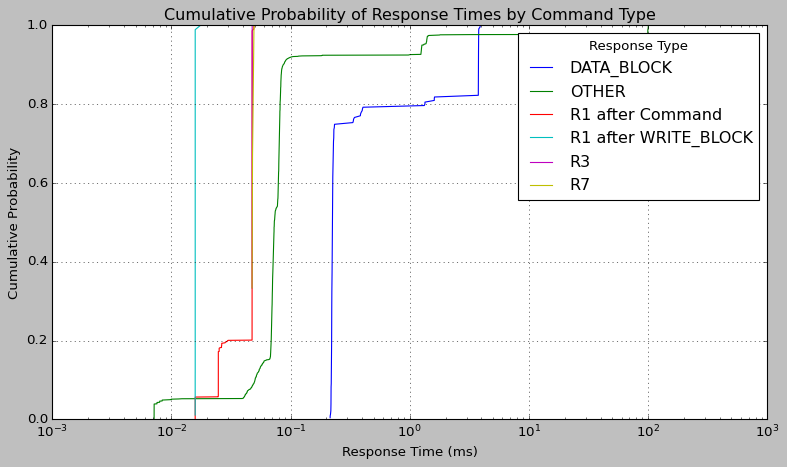

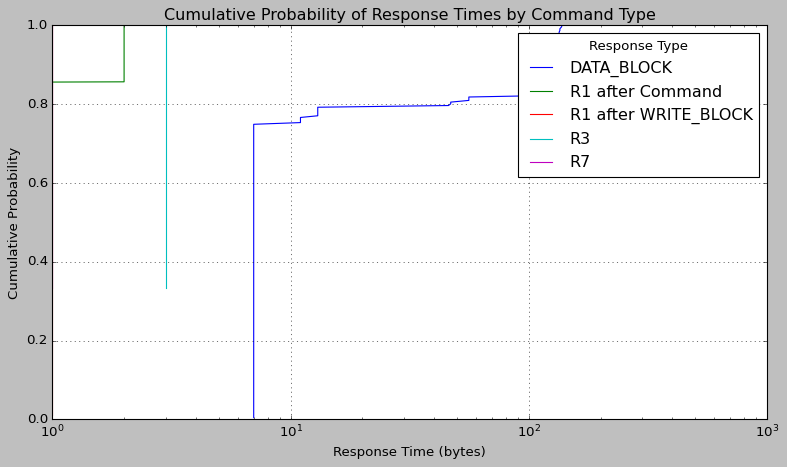

In [33]:

# Load CSV files into Pandas DataFrames
file1 = "CSVs/pi pico n1.csv"
file2 = "CSVs/pi pico n2.csv"
file3 = "CSVs/pi pico n3.csv"

# Replace these with the actual paths of your files
dataframes = [pd.read_csv(f) for f in [file1, file2, file3]]

# Combine all data into a single DataFrame
data = pd.concat(dataframes, ignore_index=True)

# Ensure 'type' and 'response_time(ms)' columns exist
if 'miso_data' not in data.columns or 'response_time(ms)' not in data.columns:
    raise ValueError("Missing required columns: 'miso_data' or 'response_time(ms)'")


# Add a column for the previous MOSI data
data['previous_mosi'] = data['mosi_data'].shift(1)

# Apply grouping
data['group'] = data.apply(group_miso_data, axis=1)

# Group data by 'group'
grouped = data.groupby('group')

# Create cumulative probability plots
plt.figure(figsize=(10, 6))

for command_type, group in grouped:
    response_times = group['response_time(ms)'].dropna()
    if not response_times.empty:
        sorted_times = np.sort(response_times)
        cumulative_probs = np.arange(1, len(sorted_times) + 1) / len(sorted_times)
        plt.semilogx(sorted_times, cumulative_probs, label=command_type)

# Add plot details
plt.title('Cumulative Probability of Response Times by Command Type')
plt.xlabel('Response Time (ms)')
plt.ylabel('Cumulative Probability')
plt.legend(title='Response Type')
plt.grid(True)

# Save or show the plot
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))

for command_type, group in grouped:
    response_times = group['response_time(bytes)'].dropna()
    if not response_times.empty:
        sorted_times = np.sort(response_times)
        cumulative_probs = np.arange(1, len(sorted_times) + 1) / len(sorted_times)
        plt.semilogx(sorted_times, cumulative_probs, label=command_type)

# Add plot details
plt.title('Cumulative Probability of Response Times by Command Type')
plt.xlabel('Response Time (bytes)')
plt.ylabel('Cumulative Probability')
plt.legend(title='Response Type')
plt.grid(True)


# Save or show the plot
plt.tight_layout()
plt.show()

